# Hotel Reservation Cancellation Prediction

**Objective:** Build a model that predicts whether a hotel booking will be cancelled, identify the strongest drivers of cancellation, and turn the findings into recommendations for the hotel.

**Pipeline in this notebook:**
1. Setup & data loading
2. Data understanding (structure, quality checks)
3. Exploratory Data Analysis (EDA)
4. Feature engineering
5. Preprocessing pipeline
6. Baseline model comparison
7. Hyperparameter tuning of the top models
8. Final model selection & evaluation
9. Feature importance & business recommendations
10. Saving the model for Streamlit deployment

> Run the cells in order, top to bottom. If you are using Google Colab, upload `Hotel_Reservations.csv` when prompted in the cell below (or place it in the same folder as this notebook if running locally).

## 1. Setup & Data Loading

In [1]:
# If you are missing any package, uncomment the line below and run it once
#!pip install pandas numpy scikit-learn matplotlib seaborn xgboost joblib -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

RANDOM_STATE = 42

In [2]:
# --- Load the dataset ---
# Option A: Running in Google Colab and the file is NOT already in the Colab file system
# Uncomment these two lines to upload it manually:
# from google.colab import files
# uploaded = files.upload()

# Option B: The file is already in the working directory (Colab or local)
DATA_PATH = "Hotel Reservations.csv"
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()

Shape: (36275, 19)


,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


## 2. Data Understanding

Before touching the data, let's confirm its structure, data types, and quality (missing values, duplicates, obvious errors).

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            36275 non-null  str    
 1   no_of_adults                          36275 non-null  int64  
 2   no_of_children                        36275 non-null  int64  
 3   no_of_weekend_nights                  36275 non-null  int64  
 4   no_of_week_nights                     36275 non-null  int64  
 5   type_of_meal_plan                     36275 non-null  str    
 6   required_car_parking_space            36275 non-null  int64  
 7   room_type_reserved                    36275 non-null  str    
 8   lead_time                             36275 non-null  int64  
 9   arrival_year                          36275 non-null  int64  
 10  arrival_month                         36275 non-null  int64  
 11  arrival_date              

In [ ]:
df.describe(include='number').T

In [27]:
numeric=df.select_dtypes(include='number').shape[1]
print(f'{round(numeric/df.shape[1],1)*100}% of the dataset is numeric')
print(f"{round((df.shape[1]-numeric)/df.shape[1],1)*100}% of the dataset is not numeric")

70.0% of the dataset is numeric
30.0% of the dataset is not numeric


In [37]:
print('<----------------------Numeric------------------------------------>')
for numeric_feature in df.select_dtypes(include='number').columns.tolist():
    print(numeric_feature)
print('<----------------------Non-numeric------------------------------>')
for non_numeric in df.select_dtypes(include='object').columns.tolist():
    print(non_numeric)


<----------------------Numeric------------------------------------>
no_of_adults
no_of_children
no_of_weekend_nights
no_of_week_nights
required_car_parking_space
lead_time
arrival_year
arrival_month
arrival_date
repeated_guest
no_of_previous_cancellations
no_of_previous_bookings_not_canceled
avg_price_per_room
no_of_special_requests
<----------------------Non-numeric------------------------------>
Booking_ID
type_of_meal_plan
room_type_reserved
market_segment_type
booking_status


In [38]:
print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0] if df.isnull().sum().sum() > 0 else "No missing values found.")

print("\nDuplicate rows:", df.duplicated().sum())

Missing values per column:
No missing values found.

Duplicate rows: 0


In [61]:
# Target variable distribution
print(df["booking_status"].value_counts())
print(df["booking_status"].value_counts(normalize=True).round(3))
print(f'{df['booking_status'].value_counts().sum()} total objects in the target variable,  compare {df.shape[0]}')

booking_status
Not_Canceled    24390
Canceled        11885
Name: count, dtype: int64
booking_status
Not_Canceled    0.672
Canceled        0.328
Name: proportion, dtype: float64
36275 total objects in the target variable,  compare 36275


**Note on class balance:** roughly 33% of bookings are cancelled and 67% are not. This is a moderate imbalance — not severe enough to require SMOTE/undersampling, but we will still track **precision, recall, F1, and ROC-AUC** alongside accuracy, since accuracy alone can be misleading on imbalanced data.

## 3. Exploratory Data Analysis (EDA)

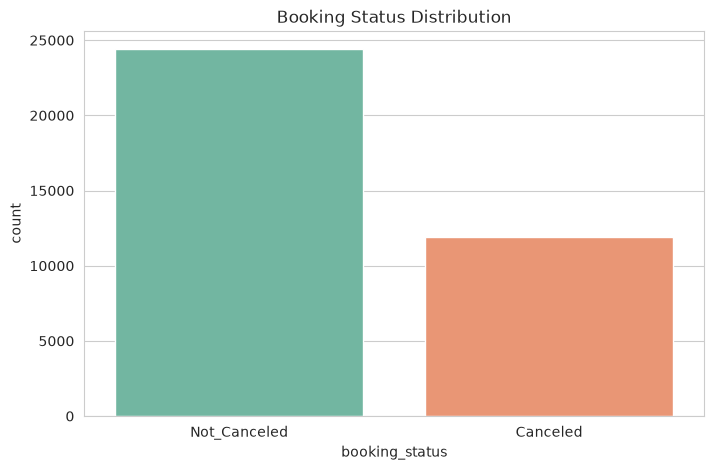

In [40]:
fig, ax = plt.subplots()
sns.countplot(data=df, x="booking_status", ax=ax, palette="Set2")
ax.set_title("Booking Status Distribution")
plt.show()

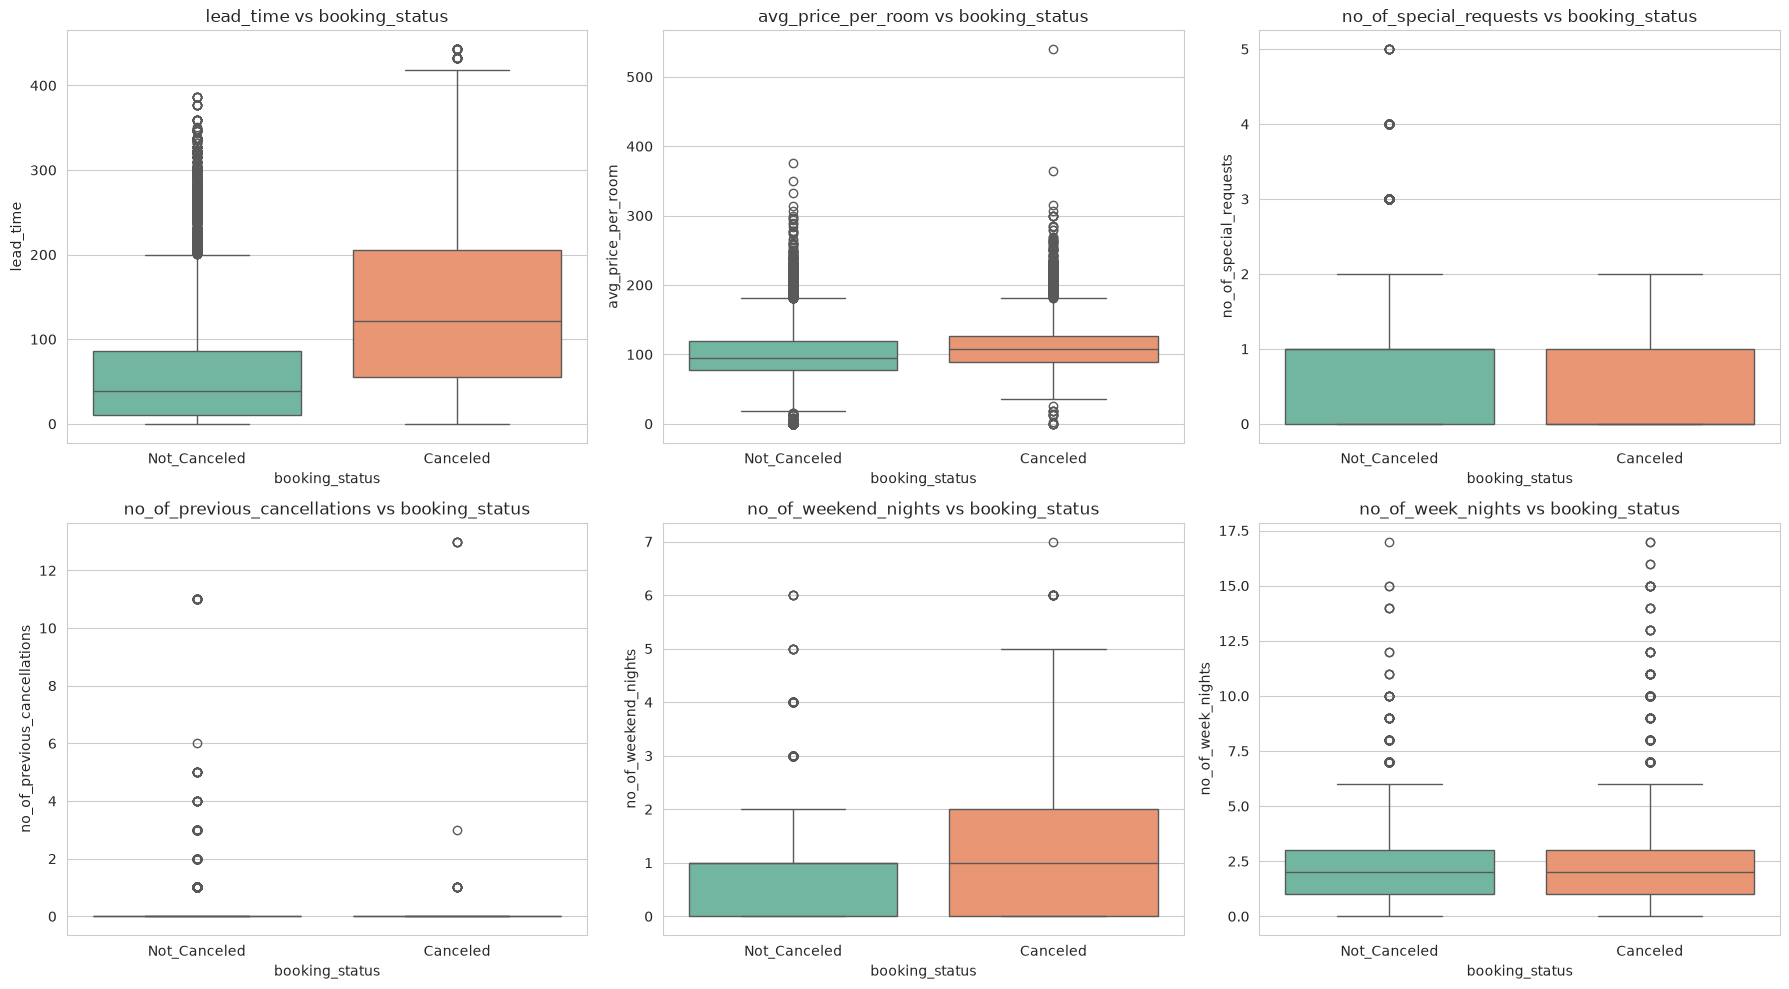

In [41]:
# Numerical features vs cancellation
num_features = ["lead_time", "avg_price_per_room", "no_of_special_requests",
                 "no_of_previous_cancellations", "no_of_weekend_nights", "no_of_week_nights"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(num_features):
    sns.boxplot(data=df, x="booking_status", y=col, ax=axes[i], palette="Set2")
    axes[i].set_title(f"{col} vs booking_status")
plt.tight_layout()
plt.show()

`lead_time` (days between booking and arrival) is typically the strongest single predictor: bookings made far in advance are more likely to be cancelled.

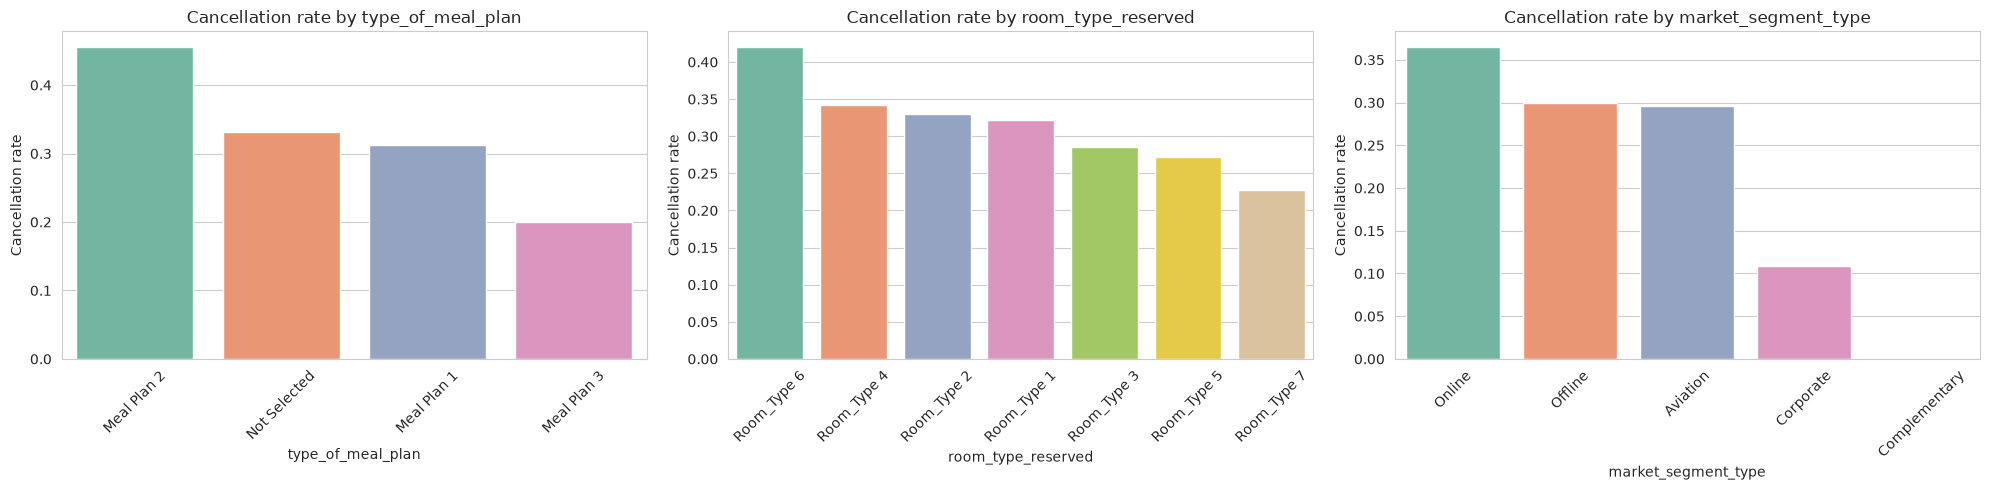

In [42]:
# Categorical features vs cancellation rate
cat_features = ["type_of_meal_plan", "room_type_reserved", "market_segment_type"]

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for i, col in enumerate(cat_features):
    rate = df.groupby(col)["booking_status"].apply(lambda x: (x == "Canceled").mean()).sort_values(ascending=False)
    sns.barplot(x=rate.index, y=rate.values, ax=axes[i], palette="Set2")
    axes[i].set_title(f"Cancellation rate by {col}")
    axes[i].set_ylabel("Cancellation rate")
    axes[i].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

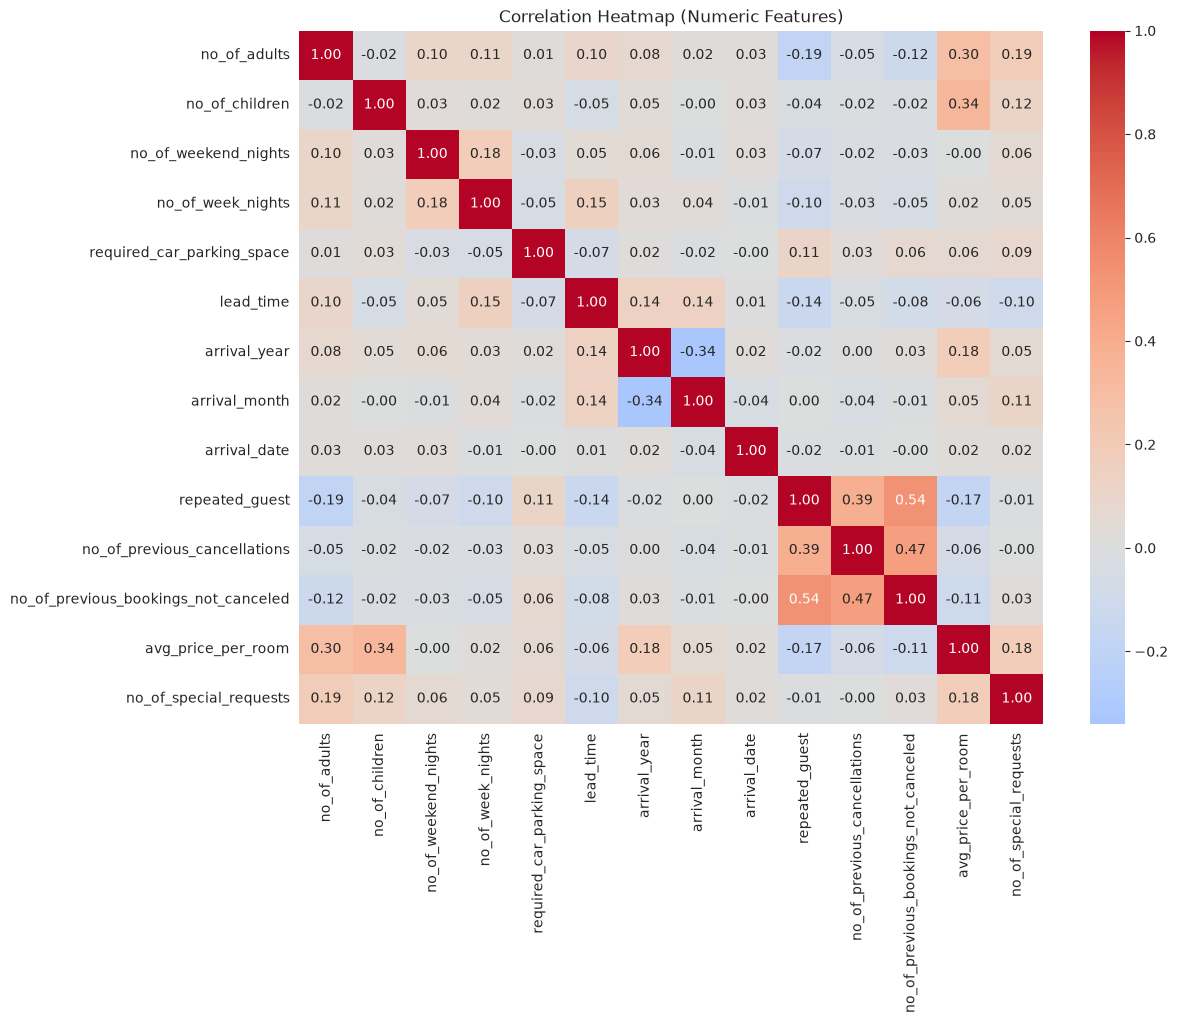

In [43]:
# Correlation heatmap of numeric features
plt.figure(figsize=(12, 9))
numeric_df = df.select_dtypes(include=np.number)
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()

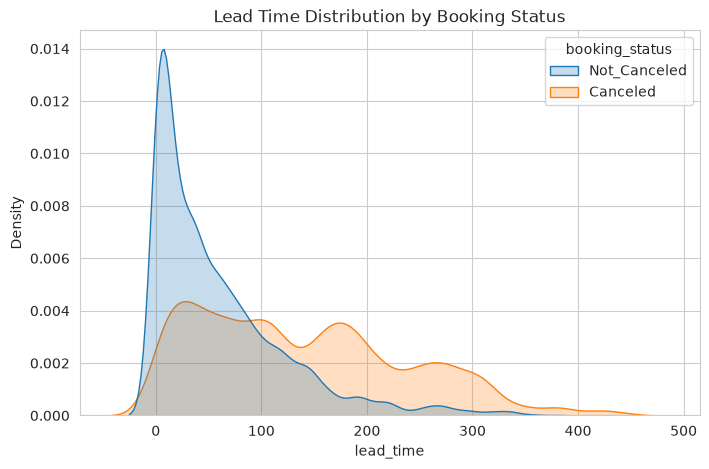

In [44]:
# Lead time distribution split by cancellation
fig, ax = plt.subplots()
sns.kdeplot(data=df, x="lead_time", hue="booking_status", fill=True, common_norm=False, ax=ax)
ax.set_title("Lead Time Distribution by Booking Status")
plt.show()

## 4. Feature Engineering

We add a few engineered features that are common drivers of cancellation risk in hotel booking datasets:

- `total_nights` = weekend nights + week nights
- `total_guests` = adults + children
- `total_previous_bookings` = previous cancellations + previous non-cancelled bookings
- `prior_cancel_rate` = share of a guest's past bookings that were cancelled (0 if no history)
- `has_special_requests` = whether the guest made at least one special request (guests with requests tend to be more committed)

We also drop `Booking_ID` since it is just an identifier with no predictive value.

In [45]:
data = df.copy()

data["total_nights"] = data["no_of_weekend_nights"] + data["no_of_week_nights"]
data["total_guests"] = data["no_of_adults"] + data["no_of_children"]
data["total_previous_bookings"] = data["no_of_previous_cancellations"] + data["no_of_previous_bookings_not_canceled"]
data["prior_cancel_rate"] = (
    data["no_of_previous_cancellations"] / data["total_previous_bookings"].replace(0, np.nan)
).fillna(0)
data["has_special_requests"] = (data["no_of_special_requests"] > 0).astype(int)

data = data.drop(columns=["Booking_ID"])

# Encode target: Canceled = 1, Not_Canceled = 0
data["booking_status"] = data["booking_status"].map({"Not_Canceled": 0, "Canceled": 1})

data.head()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,...,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status,total_nights,total_guests,total_previous_bookings,prior_cancel_rate,has_special_requests
0,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,...,0,0,65.00,0,0,3,2,0,0.0,0
1,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,...,0,0,106.68,1,0,5,2,0,0.0,1
2,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,...,0,0,60.00,0,1,3,1,0,0.0,0
3,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,...,0,0,100.00,0,1,2,2,0,0.0,0
4,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,...,0,0,94.50,0,1,2,2,0,0.0,0


## 5. Train/Test Split & Preprocessing Pipeline

We build a single `ColumnTransformer` (scaling for numeric features, one-hot encoding for categorical features) wrapped inside an sklearn `Pipeline`. Using a pipeline means the exact same preprocessing is automatically applied at prediction time in the Streamlit app — no risk of train/inference mismatch.

In [46]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

TARGET = "booking_status"
X = data.drop(columns=[TARGET])
y = data[TARGET]

cat_cols = X.select_dtypes(include="object").columns.tolist()
num_cols = X.select_dtypes(exclude="object").columns.tolist()
print("Categorical columns:", cat_cols)
print("Numerical columns:", num_cols)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

Categorical columns: ['type_of_meal_plan', 'room_type_reserved', 'market_segment_type']
Numerical columns: ['no_of_adults', 'no_of_children', 'no_of_weekend_nights', 'no_of_week_nights', 'required_car_parking_space', 'lead_time', 'arrival_year', 'arrival_month', 'arrival_date', 'repeated_guest', 'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled', 'avg_price_per_room', 'no_of_special_requests', 'total_nights', 'total_guests', 'total_previous_bookings', 'prior_cancel_rate', 'has_special_requests']
Train shape: (29020, 22)  Test shape: (7255, 22)


In [47]:
preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

## 6. Baseline Model Comparison

We train several classifiers with default (or near-default) settings, all wrapped in the same preprocessing pipeline, and compare them on the held-out test set.

In [48]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay
)

candidate_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "KNN": KNeighborsClassifier(),
    "XGBoost": XGBClassifier(random_state=RANDOM_STATE, eval_metric="logloss")
}

fitted_pipelines = {}
results = []

for name, model in candidate_models.items():
    pipe = Pipeline([("preprocessor", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1": f1_score(y_test, preds),
        "ROC_AUC": roc_auc_score(y_test, proba)
    })
    fitted_pipelines[name] = pipe

results_df = pd.DataFrame(results).sort_values("F1", ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Random Forest,0.904893,0.887104,0.813210,0.848551,0.956242
1,XGBoost,0.898139,0.871597,0.808162,0.838682,0.954599
2,Decision Tree,0.869331,0.797832,0.805217,0.801508,0.855435
3,KNN,0.854307,0.794643,0.748843,0.771063,0.902773
4,Gradient Boosting,0.857064,0.830375,0.708456,0.764586,0.922116
5,Logistic Regression,0.818057,0.757931,0.653345,0.701762,0.871174


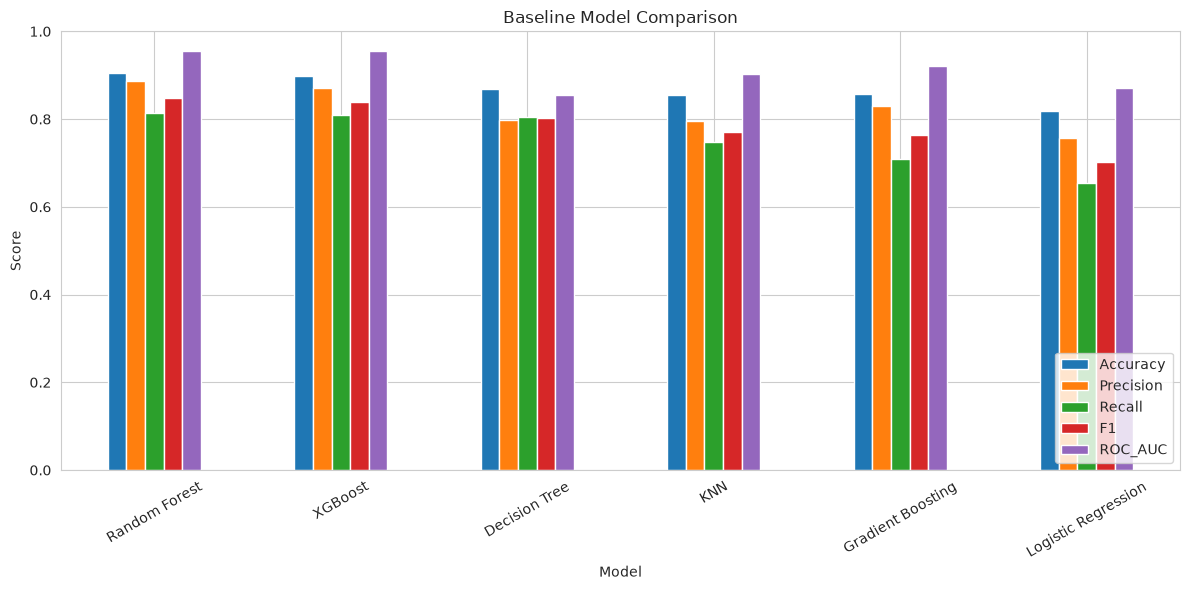

In [49]:
# Visual comparison of models
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1", "ROC_AUC"]
results_df.set_index("Model")[metrics_to_plot].plot(kind="bar", figsize=(12, 6))
plt.title("Baseline Model Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

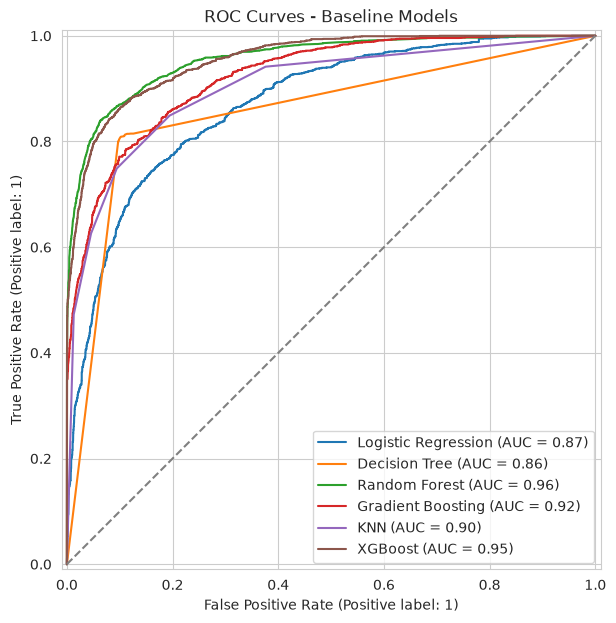

In [20]:
# ROC curves for all baseline models
fig, ax = plt.subplots(figsize=(8, 7))
for name, pipe in fitted_pipelines.items():
    RocCurveDisplay.from_estimator(pipe, X_test, y_test, ax=ax, name=name)
ax.plot([0, 1], [0, 1], linestyle="--", color="grey")
ax.set_title("ROC Curves - Baseline Models")
plt.show()

Based on the comparison above, we take the **top 2 models by F1-score** forward into hyperparameter tuning (F1 is a good primary metric here since we care about balancing false positives — flagging a booking as at-risk when it isn't — against false negatives — missing a booking that will actually cancel).

## 7. Hyperparameter Tuning

In [21]:
top_2_models = results_df["Model"].head(2).tolist()
print("Tuning:", top_2_models)

Tuning: ['Random Forest', 'XGBoost']


In [22]:
from sklearn.model_selection import RandomizedSearchCV

param_distributions = {
    "Random Forest": {
        "model__n_estimators": [200, 300, 400, 500],
        "model__max_depth": [None, 10, 20, 30],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4],
        "model__max_features": ["sqrt", "log2"]
    },
    "XGBoost": {
        "model__n_estimators": [200, 300, 400, 500],
        "model__max_depth": [3, 4, 5, 6, 8],
        "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
        "model__subsample": [0.7, 0.8, 0.9, 1.0],
        "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0]
    },
    "Gradient Boosting": {
        "model__n_estimators": [100, 200, 300],
        "model__max_depth": [2, 3, 4, 5],
        "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
        "model__subsample": [0.7, 0.8, 0.9, 1.0]
    },
    "Decision Tree": {
        "model__max_depth": [5, 10, 15, 20, None],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4]
    },
    "Logistic Regression": {
        "model__C": [0.01, 0.1, 1, 10, 100],
        "model__penalty": ["l2"]
    },
    "KNN": {
        "model__n_neighbors": [3, 5, 7, 9, 11],
        "model__weights": ["uniform", "distance"]
    }
}

tuned_pipelines = {}

for name in top_2_models:
    base_pipe = Pipeline([("preprocessor", preprocessor), ("model", candidate_models[name])])
    search = RandomizedSearchCV(
        base_pipe,
        param_distributions=param_distributions[name],
        n_iter=20,
        scoring="f1",
        cv=5,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=1
    )
    search.fit(X_train, y_train)
    tuned_pipelines[name] = search.best_estimator_
    print(f"\n{name} best params: {search.best_params_}")
    print(f"{name} best CV F1: {search.best_score_:.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Random Forest best params: {'model__n_estimators': 200, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': 'sqrt', 'model__max_depth': 30}
Random Forest best CV F1: 0.8367
Fitting 5 folds for each of 20 candidates, totalling 100 fits

XGBoost best params: {'model__subsample': 1.0, 'model__n_estimators': 500, 'model__max_depth': 8, 'model__learning_rate': 0.1, 'model__colsample_bytree': 0.7}
XGBoost best CV F1: 0.8391


## 8. Final Model Selection & Evaluation

In [23]:
final_results = []
for name, pipe in tuned_pipelines.items():
    preds = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, 1]
    final_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1": f1_score(y_test, preds),
        "ROC_AUC": roc_auc_score(y_test, proba)
    })

final_results_df = pd.DataFrame(final_results).sort_values("F1", ascending=False).reset_index(drop=True)
final_results_df

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Random Forest,0.905445,0.886957,0.815313,0.849627,0.956387
1,XGBoost,0.903928,0.875335,0.824148,0.848971,0.960834


In [24]:
BEST_MODEL_NAME = final_results_df.iloc[0]["Model"]
best_pipeline = tuned_pipelines[BEST_MODEL_NAME]
print(f"Best model selected: {BEST_MODEL_NAME}")

Best model selected: Random Forest


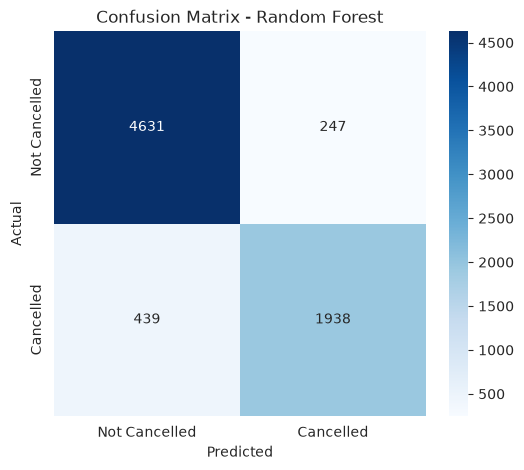

               precision    recall  f1-score   support

Not Cancelled       0.91      0.95      0.93      4878
    Cancelled       0.89      0.82      0.85      2377

     accuracy                           0.91      7255
    macro avg       0.90      0.88      0.89      7255
 weighted avg       0.90      0.91      0.90      7255



In [25]:
# Confusion matrix for the best model
preds = best_pipeline.predict(X_test)
cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not Cancelled", "Cancelled"],
            yticklabels=["Not Cancelled", "Cancelled"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - {BEST_MODEL_NAME}")
plt.show()

print(classification_report(y_test, preds, target_names=["Not Cancelled", "Cancelled"]))

In [26]:
# Cross-validated stability check on the full training data
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(best_pipeline, X_train, y_train, cv=5, scoring="f1", n_jobs=-1)
print(f"5-fold CV F1 scores: {np.round(cv_scores, 4)}")
print(f"Mean: {cv_scores.mean():.4f}  Std: {cv_scores.std():.4f}")

5-fold CV F1 scores: [0.8409 0.8275 0.8311 0.8372 0.847 ]
Mean: 0.8367  Std: 0.0069


## 9. Feature Importance & Business Recommendations

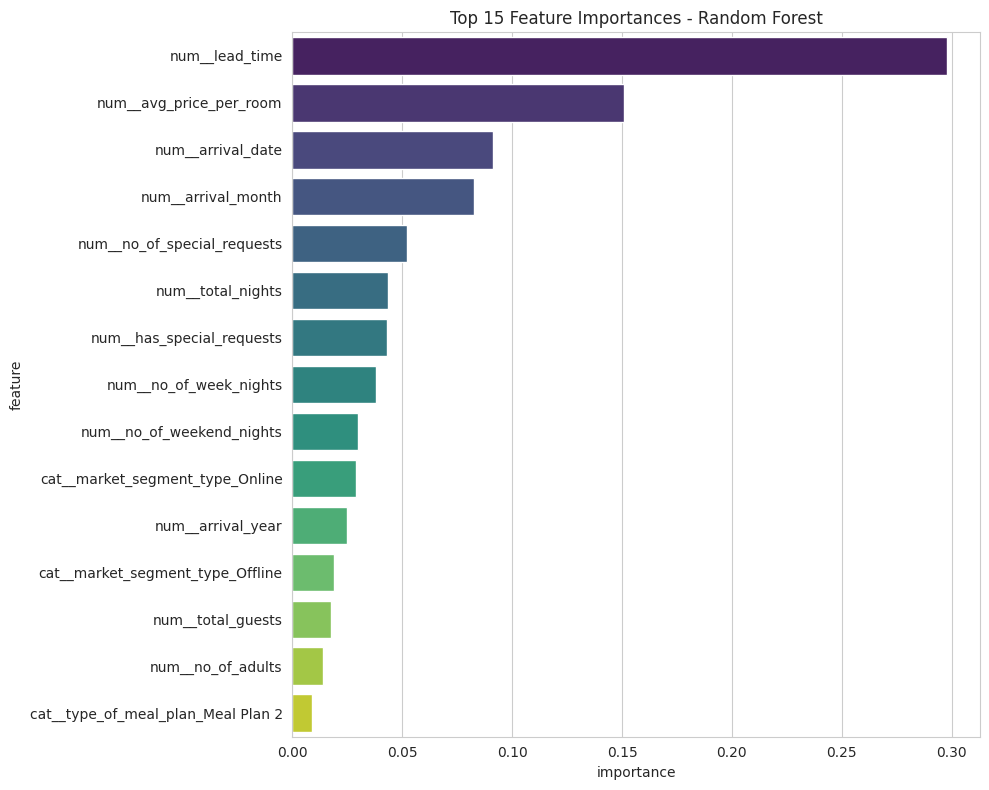

In [24]:
# Extract feature importances (works for tree-based models: Random Forest, XGBoost, Gradient Boosting, Decision Tree)
model_step = best_pipeline.named_steps["model"]
preprocessor_step = best_pipeline.named_steps["preprocessor"]

feature_names = preprocessor_step.get_feature_names_out()

if hasattr(model_step, "feature_importances_"):
    importances = model_step.feature_importances_
    imp_df = pd.DataFrame({"feature": feature_names, "importance": importances}) \
                .sort_values("importance", ascending=False).head(15)

    plt.figure(figsize=(10, 8))
    sns.barplot(data=imp_df, x="importance", y="feature", palette="viridis")
    plt.title(f"Top 15 Feature Importances - {BEST_MODEL_NAME}")
    plt.tight_layout()
    plt.show()
else:
    print(f"{BEST_MODEL_NAME} does not expose feature_importances_ directly (e.g. Logistic Regression uses coefficients instead).")
    if hasattr(model_step, "coef_"):
        coef_df = pd.DataFrame({"feature": feature_names, "coefficient": model_step.coef_[0]}) \
                    .sort_values("coefficient", key=abs, ascending=False).head(15)
        plt.figure(figsize=(10, 8))
        sns.barplot(data=coef_df, x="coefficient", y="feature", palette="viridis")
        plt.title(f"Top 15 Coefficients (by magnitude) - {BEST_MODEL_NAME}")
        plt.tight_layout()
        plt.show()

### Recommendations for the hotel (fill in / adjust after reviewing your own results above)

Typical patterns seen in this kind of dataset — check the feature importance chart above to confirm these hold for your specific run:

- **Long lead times increase cancellation risk.** Consider a tiered deposit or a confirmation reminder policy for bookings made far in advance.
- **Higher average room price is associated with more cancellations.** Flexible-price bookings might benefit from a stricter cancellation policy or a small non-refundable deposit.
- **Guests with special requests cancel less often.** This signals genuine intent to stay — such guests could be lower priority for overbooking-risk management.
- **Online market segment bookings tend to cancel more than corporate/offline.** The hotel could tighten confirmation requirements (e.g. card verification) for online bookings specifically.
- **Repeat guests and guests with a track record of completed stays cancel less.** A loyalty-based flexible policy could reward this pattern without adding risk.

Adjust this list to match what your own chart actually shows before submitting the project — the exact ranking can shift slightly depending on the random seed and tuning results.

## 10. Saving the Model for Streamlit Deployment

We save the **entire fitted pipeline** (preprocessing + model together) as a single `.pkl` file. This is important: the Streamlit app only needs to load this one file and call `.predict()` — it does not need to reimplement any encoding or scaling logic.

In [ ]:
import joblib

MODEL_PATH = "best_model_pipeline.pkl"
joblib.dump(best_pipeline, MODEL_PATH, compress=3)  # compress=3 keeps the file small enough for GitHub/Streamlit Cloud
print(f"Saved best pipeline ({BEST_MODEL_NAME}) to {MODEL_PATH}")

# Also save the list of raw input columns and their dtypes, so the Streamlit app
# can build a matching input form automatically.
column_info = {
    "columns": X.columns.tolist(),
    "cat_cols": cat_cols,
    "num_cols": num_cols,
    "cat_options": {c: sorted(X[c].dropna().unique().tolist()) for c in cat_cols},
    "num_ranges": {c: (float(X[c].min()), float(X[c].max())) for c in num_cols},
    "best_model_name": BEST_MODEL_NAME
}
joblib.dump(column_info, "column_info.pkl")
print("Saved column_info.pkl (used by the Streamlit app to build the input form)")

**Next step:** download `best_model_pipeline.pkl` and `column_info.pkl` from this notebook's file browser (in Colab: the folder icon on the left) and place them in the same folder as the `app.py` Streamlit app provided separately. Then run:

```bash
streamlit run app.py
```